# **Error analysis**

In [38]:
import logging
import pandas as pd
import numpy as np
import os 
import sys

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

### **logging configuration**

In [39]:
LOG_FILE = r"C:\Users\mrcoo\Machine-Learning-full-course-main\month_4\model_building_lesson_11\main\error.log"
DATA_FILE = r"C:\Users\mrcoo\Machine-Learning-full-course-main\month_4\model_building_lesson_11\main\ai-impact-jobs-layoff-risk-dataset.csv"


logging.basicConfig(
    filename = LOG_FILE,
    filemode='a',
    level=logging.INFO,
    format="%(asctime)s-%(levelname)s-%(message)s"
)

logging.info("Logging | Test!")

### **Data loading**

In [40]:
sys.path.append(r"C:\Users\mrcoo\Machine-Learning-full-course-main\month_4\model_building_lesson_11\main\error_analysis.py")

from error_analysis import DataLoader
loading = DataLoader(DATA_FILE)

df = loading.load(DATA_FILE)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

### **Numerical and categorical columns**

In [42]:
num_col = df.select_dtypes(include=[np.number]).columns.tolist()
cat_col = df.select_dtypes(exclude=[np.number]).columns.drop("Layoff_Risk").tolist()

print(f"Numerical columns: {num_col}")
print(f"Categorical columns: {cat_col}")

Numerical columns: ['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours']
Categorical columns: ['Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level', 'AI_Adoption_Level']


### **Turning categorical columns into str**

In [43]:
for col in cat_col:
    df[col] = df[col].astype(str)

if "Layoff_Risk" not in df.columns:
    print(f"Column not found")
    print(f"{df.colums.tolist()}")
else:
    X = df.drop("Layoff_Risk", axis=1)
    y = df["Layoff_Risk"]

### **Pipeline for numerical columns**

In [44]:
num_pipeline = Pipeline([
("imputer", SimpleImputer(strategy="mean")),
("scaler", MinMaxScaler())
])

num_pipeline


Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', MinMaxScaler())])

### **Pipeline for categorical columns**

In [45]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1))])

### **Creating preprocessor based on those pipelines**

In [46]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_col),
    ('cat', cat_pipeline, cat_col)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', MinMaxScaler())]),
                                 ['Age', 'Years_of_Experience',
                                  'Routine_Task_Percentage',
                                  'Creativity_Requirement',
                                  'Human_Interaction_Level',
                                  'Number_of_AI_Tools_Used',
                                  'AI_Usage_Hours_Per_Week',
                                  'Tasks_Automated_Percentage',
                                  'AI_Training_Hours']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Education_Level', 'Industry', 'Job_Role',
                                  'Company_Size', 'Job_Level',
                                  'AI_Adoption_Level'])])

### **Creating Main Pipeline**

In [47]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Age', 'Years_of_Experience',
                                                   'Routine_Task_Percentage',
                                                   'Creativity_Requirement',
                                                   'Human_Interaction_Level',
                                                   'Number_of_AI_Tools_Used',
                                                   'AI_Usage_Hours_Per_Week',
                                                   'Tasks_Automated_Percentage',
                                                   'AI_Training_Hours']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Education_Level',
                                                   'Industry', 'Job_Role',
                                                   'Company_Size', 'Job_Level',
                                                   'AI_Adoption_Level'])])),
                ('model', RandomForestClassifier(random_state=42))])

### **Training session**

In [49]:
x_train, x_test, y_train, y_test = train_test_split(X,y,random_state=42)

In [50]:
pipeline.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Age', 'Years_of_Experience',
                                                   'Routine_Task_Percentage',
                                                   'Creativity_Requirement',
                                                   'Human_Interaction_Level',
                                                   'Number_of_AI_Tools_Used',
                                                   'AI_Usage_Hours_Per_Week',
                                                   'Tasks_Automated_Percentage',
                                                   'AI_Training_Hours']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Education_Level',
                                                   'Industry', 'Job_Role',
                                                   'Company_Size', 'Job_Level',
                                                   'AI_Adoption_Level'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [52]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = pipeline.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))



Accuracy: 0.88
              precision    recall  f1-score   support

        High       0.91      0.91      0.91      1714
         Low       0.92      0.92      0.92      1639
      Medium       0.83      0.82      0.82      1647

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



### **Error analysis**

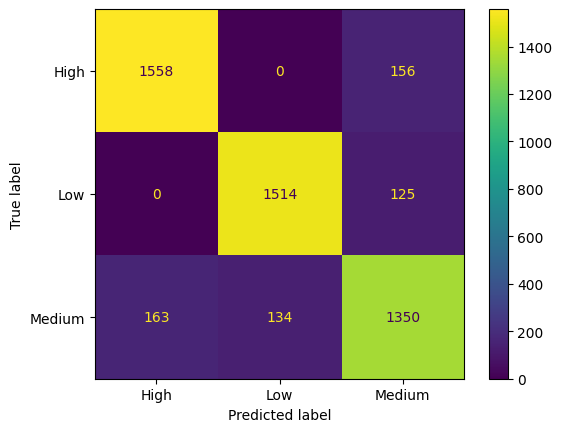

In [54]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()



In [55]:
results = x_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred

errors = results[results["Actual"] != results["Predicted"]]

print(errors.head())

       Age Education_Level  Years_of_Experience    Industry  \
8668    38      Bachelor's                   10     Telecom   
19024   39      Bachelor's                   16  Healthcare   
9119    40        Master's                    2      Retail   
16421   27      Bachelor's                    6          IT   
3941    47        Master's                   13  Healthcare   

                 Job_Role Company_Size Job_Level  Routine_Task_Percentage  \
8668   Support Specialist        Large       Mid                       44   
19024               Nurse        Small    Senior                       91   
9119      Sales Associate        Small     Entry                       12   
16421        Data Analyst       Medium     Entry                       57   
3941                Nurse        Small     Entry                       51   

       Creativity_Requirement  Human_Interaction_Level AI_Adoption_Level  \
8668                       63                       79            Medium   
19024 

In [56]:
print(y_train.value_counts())

Layoff_Risk
High      5083
Low       4963
Medium    4954
Name: count, dtype: int64


### **Analyze error by feature**

In [60]:
errors.groupby("Job_Level").size()

Job_Level
Entry     249
Mid       246
Senior     83
dtype: int64